In [51]:
# task 03 at kodbud. 
# Performing Exploratory Data Analysis at kodbud.

# Analyse and extract insights from IPL Dataset. (most winning awards, Top scoreres, Stadium trends)

In [52]:
# importing the libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [53]:
# Loading the dataset
df = pd.read_csv("Downloads/IPL_Dataset(2008-2024).csv")
df.head()

,Match_ID,Date,Teams,Venue,Toss_Winner,Toss_Decision,Match_Winner,Win_Type,Win_Margin,First_Innings_Score,Second_Innings_Score,Player_of_Match,Umpire,Umpire1,Umpire2,Powerplay_Scores,Middle_Overs_Scores,Death_Overs_Scores
0,335982,2008-04-18,Royal Challengers Bangalore vs Kolkata Knight ...,M Chinnaswamy Stadium,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,222,82.0,BB McCullum,Asad Rauf,RE Koertzen,J Srinath,61,97,64
1,335983,2008-04-19,Kings XI Punjab vs Chennai Super Kings,"Punjab Cricket Association Stadium, Mohali",Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,240,207.0,MEK Hussey,MR Benson,SL Shastri,S Venkataraghavan,53,116,71
2,335984,2008-04-19,Delhi Daredevils vs Rajasthan Royals,Feroz Shah Kotla,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,129,132.0,MF Maharoof,Aleem Dar,GA Pratapkumar,GR Viswanath,40,66,23
3,335985,2008-04-20,Mumbai Indians vs Royal Challengers Bangalore,Wankhede Stadium,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,165,166.0,MV Boucher,SJ Davis,DJ Harper,J Srinath,47,71,47
4,335986,2008-04-20,Kolkata Knight Riders vs Deccan Chargers,Eden Gardens,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,110,112.0,DJ Hussey,BF Bowden,K Hariharan,FM Engineer,39,43,28


In [54]:
df.describe()

,Match_ID,Win_Margin,First_Innings_Score,Second_Innings_Score,Powerplay_Scores,Middle_Overs_Scores,Death_Overs_Scores
count,1.073000e+03,1054.000000,1073.000000,1070.000000,1073.000000,1073.000000,1073.000000
mean,8.941365e+05,17.158444,165.164958,151.918692,46.074557,78.248835,40.841566
std,3.637486e+05,21.762303,31.904238,31.751666,12.007306,18.604148,14.228121
min,3.359820e+05,1.000000,56.000000,2.000000,15.000000,0.000000,0.000000
25%,5.483260e+05,6.000000,145.000000,134.000000,38.000000,66.000000,33.000000
50%,9.809390e+05,8.000000,165.000000,153.000000,46.000000,77.000000,41.000000
75%,1.216540e+06,19.750000,186.000000,172.000000,53.000000,90.000000,50.000000
max,1.426287e+06,146.000000,287.000000,262.000000,125.000000,155.000000,89.000000


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1073 entries, 0 to 1072
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Match_ID              1073 non-null   int64  
 1   Date                  1073 non-null   object 
 2   Teams                 1073 non-null   object 
 3   Venue                 1073 non-null   object 
 4   Toss_Winner           1073 non-null   object 
 5   Toss_Decision         1073 non-null   object 
 6   Match_Winner          1073 non-null   object 
 7   Win_Type              1054 non-null   object 
 8   Win_Margin            1054 non-null   float64
 9   First_Innings_Score   1073 non-null   int64  
 10  Second_Innings_Score  1070 non-null   float64
 11  Player_of_Match       1068 non-null   object 
 12  Umpire                1073 non-null   object 
 13  Umpire1               1073 non-null   object 
 14  Umpire2               1073 non-null   object 
 15  Powerplay_Scores     

In [56]:
print("Shape of Row:", df.shape[0])
print("Shape of Columns:", df.shape[1])

Shape of Row: 1073
Shape of Columns: 18


In [57]:
df.isnull().sum()

Match_ID                 0
Date                     0
Teams                    0
Venue                    0
Toss_Winner              0
Toss_Decision            0
Match_Winner             0
Win_Type                19
Win_Margin              19
First_Innings_Score      0
Second_Innings_Score     3
Player_of_Match          5
Umpire                   0
Umpire1                  0
Umpire2                  0
Powerplay_Scores         0
Middle_Overs_Scores      0
Death_Overs_Scores       0
dtype: int64

In [58]:
df["Player_of_Match"].mode()

0    AB de Villiers
Name: Player_of_Match, dtype: object

In [59]:
df["Second_Innings_Score"].median()

153.0

EDA Questions..?

1. Does winning the toss affect winning the match?
2. Which venues have highest scoring matches?
3. Does batting first or second give an advantage?
4. Which team has highest win margin historically?
5. Are powerplay scores correlated with total innings score / win chance?

In [60]:
# Fill categorical columns
df['Win_Type'] = df['Win_Type'].fillna('Unknown')
df['Player_of_Match'] = df['Player_of_Match'].fillna('Unknown')

# Fill numeric columns
df['Win_Margin'] = df['Win_Margin'].fillna(0)
df['Second_Innings_Score'] = df['Second_Innings_Score'].fillna(df['Second_Innings_Score'].median())


In [61]:
df.isnull().sum()

Match_ID                0
Date                    0
Teams                   0
Venue                   0
Toss_Winner             0
Toss_Decision           0
Match_Winner            0
Win_Type                0
Win_Margin              0
First_Innings_Score     0
Second_Innings_Score    0
Player_of_Match         0
Umpire                  0
Umpire1                 0
Umpire2                 0
Powerplay_Scores        0
Middle_Overs_Scores     0
Death_Overs_Scores      0
dtype: int64

In [62]:
df = df[['Date', 'Teams', 'Venue', 'Toss_Winner', 'Toss_Decision',
 'Match_Winner', 'Win_Type', 'Win_Margin','First_Innings_Score','Powerplay_Scores']]
df.head(2)

,Date,Teams,Venue,Toss_Winner,Toss_Decision,Match_Winner,Win_Type,Win_Margin,First_Innings_Score,Powerplay_Scores
0,2008-04-18,Royal Challengers Bangalore vs Kolkata Knight ...,M Chinnaswamy Stadium,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,222,61
1,2008-04-19,Kings XI Punjab vs Chennai Super Kings,"Punjab Cricket Association Stadium, Mohali",Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,240,53


In [63]:
df.columns

Index(['Date', 'Teams', 'Venue', 'Toss_Winner', 'Toss_Decision',
       'Match_Winner', 'Win_Type', 'Win_Margin', 'First_Innings_Score',
       'Powerplay_Scores'],
      dtype='object')

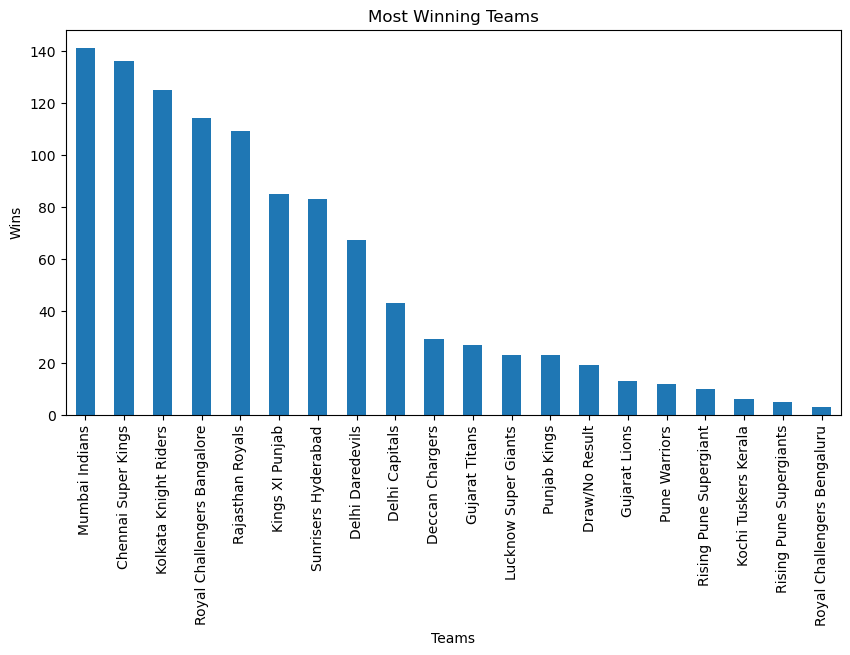

In [64]:
# univariate Analysis 
# Match Winners(Top Teams)

plt.figure(figsize=(10,5))
df["Match_Winner"].value_counts().plot(kind="bar")
plt.title("Most Winning Teams")
plt.xlabel("Teams")
plt.ylabel("Wins")
plt.show()

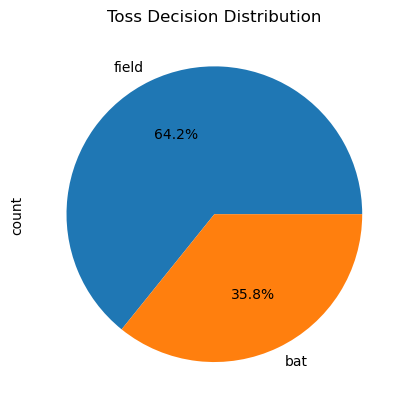

In [65]:
# Toss Decisions (Bat Vs Fielding)

df["Toss_Decision"].value_counts().plot(kind="pie",autopct= "%1.1f%%")
plt.title("Toss Decision Distribution")
plt.show()

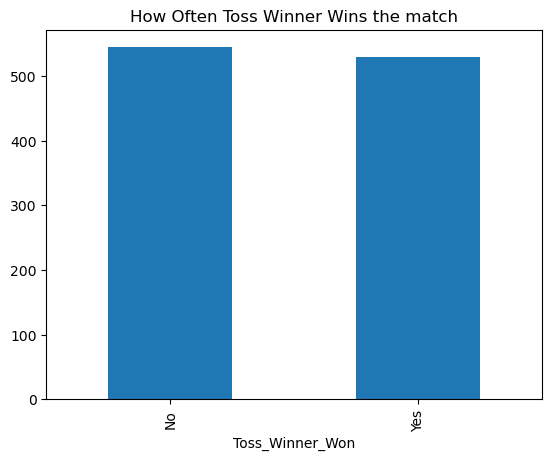

In [66]:
# Bi-variate Analysis
#  Q. Does Toss winner usually win the match

df["Toss_Winner_Won"]=df["Toss_Winner"] == df["Match_Winner"]
df["Toss_Winner_Won"].value_counts().plot(kind="bar")
plt.title("How Often Toss Winner Wins the match")
plt.xticks([0,1],["No","Yes"])
plt.show()

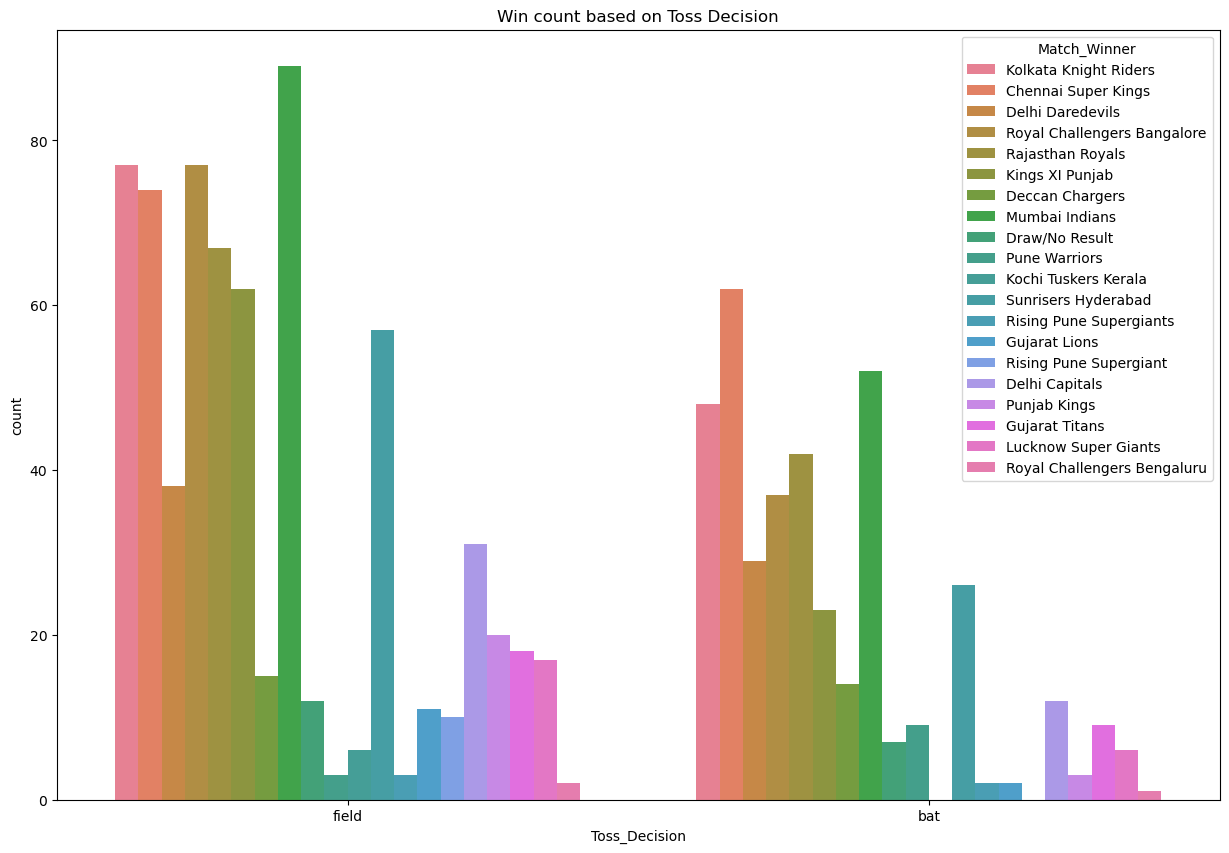

In [67]:
# Q.Bat First or Field First Win Rate.
plt.figure(figsize=(15,10))
sns.countplot(x="Toss_Decision", hue= "Match_Winner",data=df)
plt.title("Win count based on Toss Decision")
plt.show()

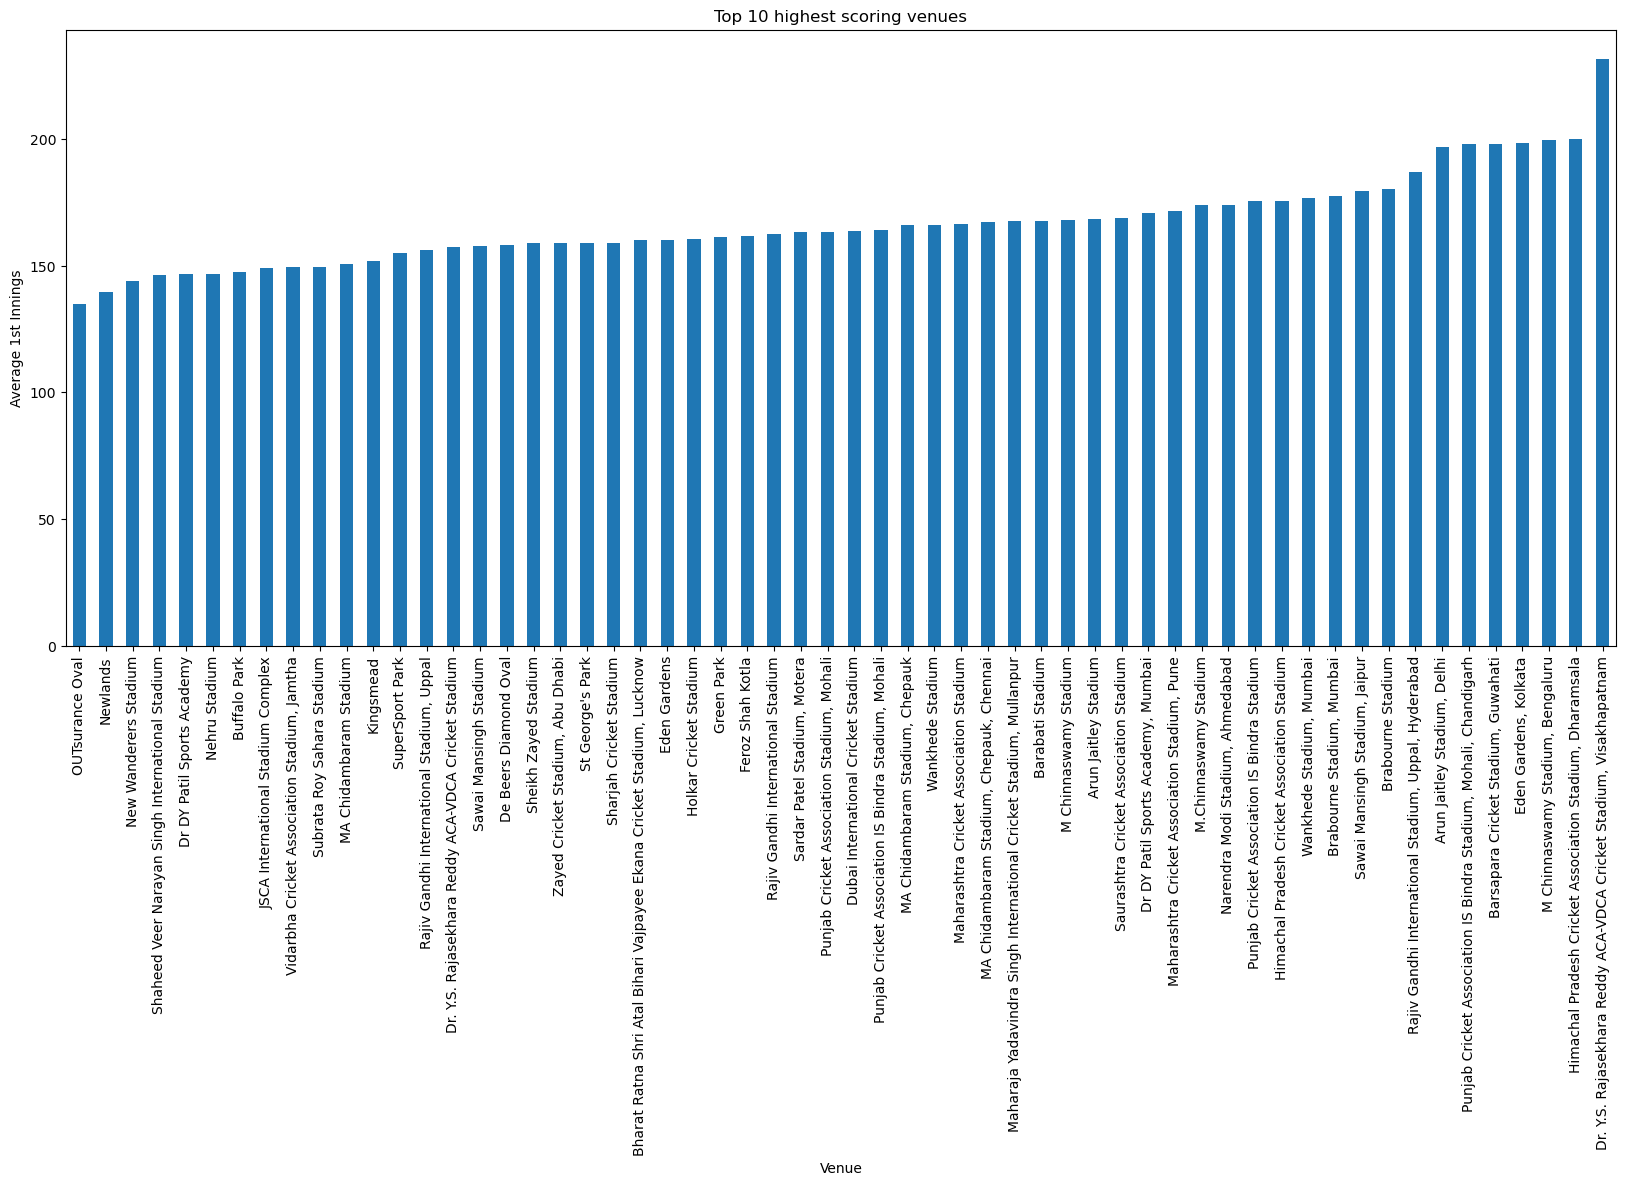

In [68]:
# Q. Which venue has the highest scoring matches?
venue_score = df.groupby("Venue")["First_Innings_Score"].mean().sort_values(ascending=True)

plt.figure(figsize=(20,8))
venue_score.plot(kind="bar")
plt.title("Top 10 highest scoring venues")
plt.ylabel("Average 1st Innings")
plt.xticks(rotation=90)
plt.show()

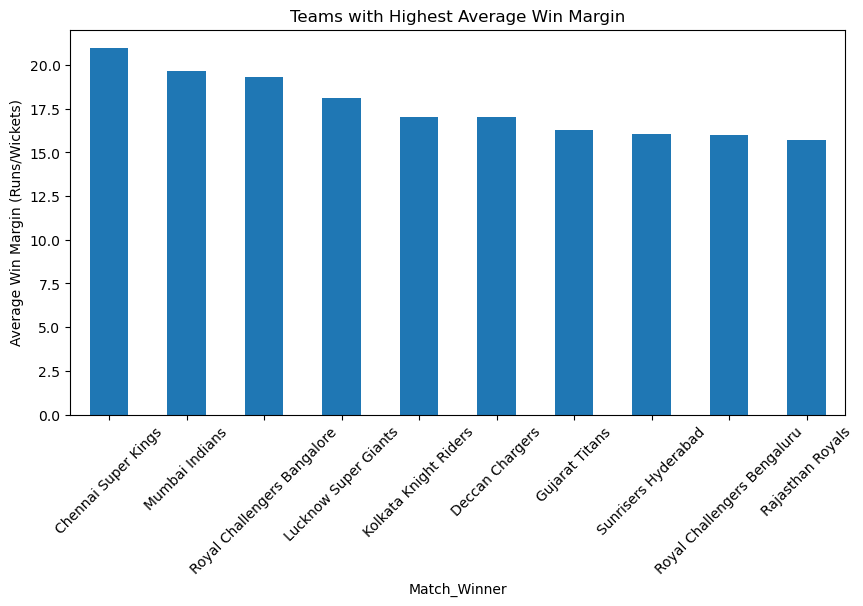

In [69]:
# Which team has the highest win margin historically?


team_margin = df.groupby('Match_Winner')['Win_Margin'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
team_margin.plot(kind='bar')
plt.title("Teams with Highest Average Win Margin")
plt.ylabel("Average Win Margin (Runs/Wickets)")
plt.xticks(rotation=45)
plt.show()

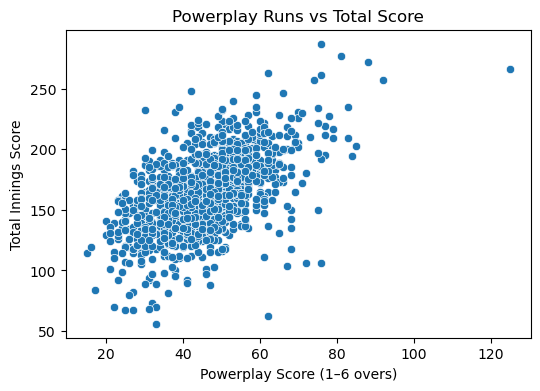

In [70]:
# Are Powerplay scores correlated with total innings score/winchance?

plt.figure(figsize=(6,4))
sns.scatterplot(x='Powerplay_Scores', y='First_Innings_Score', data=df)
plt.title("Powerplay Runs vs Total Score")
plt.xlabel("Powerplay Score (1–6 overs)")
plt.ylabel("Total Innings Score")
plt.show()

In [75]:
corr = df[['Powerplay_Scores', 'First_Innings_Score']].corr()
corr

,Powerplay_Scores,First_Innings_Score
Powerplay_Scores,1.000000,0.547496
First_Innings_Score,0.547496,1.000000


In [72]:
df.columns

Index(['Date', 'Teams', 'Venue', 'Toss_Winner', 'Toss_Decision',
       'Match_Winner', 'Win_Type', 'Win_Margin', 'First_Innings_Score',
       'Powerplay_Scores', 'Toss_Winner_Won'],
      dtype='object')

Text(0.5, 1.0, 'Correlation Heatmap of 1st Innings and powerplay_scores')

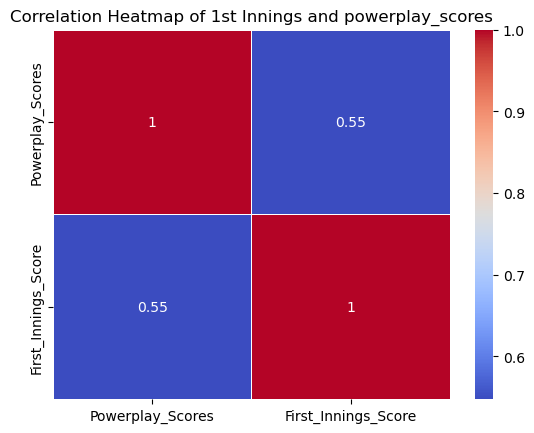

In [84]:
sns.heatmap(corr, annot=True,cmap="coolwarm", linewidth=0.5 )
plt.title("Correlation Heatmap of 1st Innings and powerplay_scores")

In [78]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = df[numeric_cols].corr()


Text(0.5, 1.0, 'Correlation Heatmap of 1st and 2nd Innings')

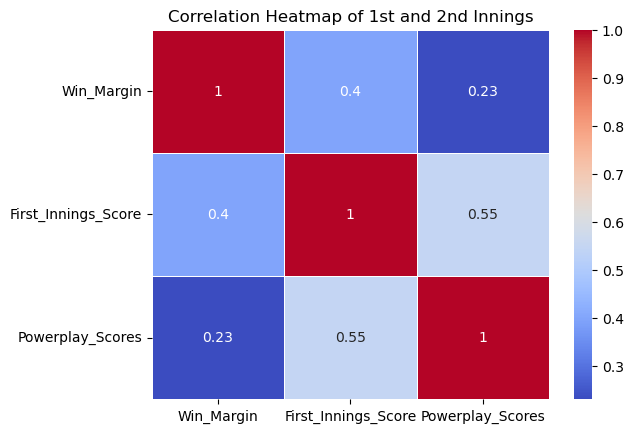

In [81]:
sns.heatmap(corr_matrix, annot=True,cmap="coolwarm", linewidth=0.5 )
plt.title("Correlation Heatmap of Numerical IPL Features")